In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
usdot_flight_delays_path = kagglehub.dataset_download('usdot/flight-delays')

print('Data source import complete.')


Using Colab cache for faster access to the 'flight-delays' dataset.
Data source import complete.


# ✈️ Flight Delay & Cancellation Analytics Platform
### Big Data Project — 2015 U.S. Flight Dataset (DOT / Kaggle)

> **Dataset:** [2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)  
> **Size:** ~5.8 million records · 31 features  
> **Tools:** PySpark · Pandas · Scikit-learn · MLlib · Matplotlib · Seaborn · MLxtend

---

## 1. 📌 Introduction & Business Understanding

### 1.1 Problem Statement

The aviation industry faces significant operational and financial challenges due to flight delays and cancellations. These disruptions affect airlines, airports, and passengers, leading to increased operational costs, poor customer satisfaction, and inefficient resource utilization.

This project builds a **data-driven analytics platform** that:
- Predicts whether a flight will be delayed
- Estimates the expected delay duration
- Discovers co-occurring delay patterns
- Segments airports by delay behavior

### 1.2 Business Impact

| Stakeholder | Problem | Platform Benefit |
|---|---|---|
| Airline Ops | Unpredictable delays cause fuel & crew waste | Proactive scheduling adjustments |
| Airport Staff | Congestion hotspots unknown | Identify high-risk windows & routes |
| Booking Platforms | Passengers uninformed | Real-time delay probability scores |
| Revenue Management | Compensation costs | Minimize disruption-driven payouts |

Flight delays cost the U.S. aviation industry **~$28 billion annually** in direct and indirect costs.

### 1.3 Objectives

**Airport Segmentation:** Use K-Means clustering to categorize airports based on operational performance and efficiency metrics.


### 1.4 Success Metrics

**Classification:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  
**Regression:** RMSE, MAE, R²  
**Business:** Delay uncertainty reduction, scheduling efficiency improvement

---
## 2. 📂 Dataset Description

### 2.1 Data Source

- **Source:** U.S. Department of Transportation (RITA/BTS)
- **Platform:** [Kaggle – 2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)
- **Files:** `flights.csv` (primary), `airlines.csv`, `airports.csv`
- **Year:** 2015 (full calendar year)

### 2.2 Dataset Overview

| Property | Value |
|---|---|
| Records | ~5.8 million |
| Features | 31 columns |
| Airlines | 14 major U.S. carriers |
| Airports | 322 origin airports |
| File Size | ~574 MB (flights.csv) |

This qualifies as **Big Data** — exceeding typical in-memory Pandas capacity.

### 2.3 Data Dictionary

| Column | Type | Description |
|---|---|---|
| YEAR / MONTH / DAY | int | Flight date components |
| DAY_OF_WEEK | int | 1=Monday … 7=Sunday |
| AIRLINE | str | IATA airline code |
| FLIGHT_NUMBER | int | Carrier flight number |
| TAIL_NUMBER | str | Aircraft registration |
| ORIGIN_AIRPORT | str | Departure airport IATA |
| DESTINATION_AIRPORT | str | Arrival airport IATA |
| SCHEDULED_DEPARTURE | int | HHMM scheduled departure |
| DEPARTURE_TIME | float | Actual departure (HHMM) |
| DEPARTURE_DELAY | float | Delay in minutes (neg=early) |
| TAXI_OUT | float | Taxi-out time (min) |
| WHEELS_OFF | float | Wheels-off time |
| SCHEDULED_TIME | float | Planned flight duration |
| ELAPSED_TIME | float | Actual flight duration |
| AIR_TIME | float | Airborne time |
| DISTANCE | int | Distance in miles |
| WHEELS_ON | float | Wheels-on time |
| TAXI_IN | float | Taxi-in time |
| SCHEDULED_ARRIVAL | int | HHMM scheduled arrival |
| ARRIVAL_TIME | float | Actual arrival |
| ARRIVAL_DELAY | float | Arrival delay (target) |
| DIVERTED | int | 1=diverted |
| CANCELLED | int | 1=cancelled |
| CANCELLATION_REASON | str | A/B/C/D |
| AIR_SYSTEM_DELAY | float | Delay from ATC |
| SECURITY_DELAY | float | Delay from security |
| AIRLINE_DELAY | float | Delay from airline |
| LATE_AIRCRAFT_DELAY | float | Delay from late aircraft |
| WEATHER_DELAY | float | Delay from weather |

### 2.4 Big Data Considerations

- Full dataset (~574 MB) exceeds comfortable Pandas RAM usage
- **PySpark** used for distributed processing
- **Pandas** used on sampled subsets for EDA visualizations
- Memory partitioning and caching strategies applied

---
## 3. ⚙️ Environment Setup & Libraries

### 3.1 Import Libraries

In [2]:
import os
import sys
import warnings
import logging

# Suppress Python warnings
warnings.filterwarnings("ignore")

# Suppress logging noise
logging.getLogger().setLevel(logging.ERROR)

# LAST RESORT: silence stderr spam
sys.stderr = open(os.devnull, 'w')

In [3]:
import os
import sys
import time
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.fpm import FPGrowth as SparkFPGrowth

# Suppress logs and warnings
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
logging.getLogger('py4j').setLevel(logging.ERROR)
logging.getLogger('pyspark').setLevel(logging.ERROR)

# Visualization Defaults
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 14, 'font.family': 'DejaVu Sans'})
sns.set_theme(style='whitegrid', palette='husl')

### 3.2 Configuration

In [4]:
LOCAL_DATA_PATH = "data/"
KAGGLE_DATA_PATH = "/kaggle/input/datasets/organizations/usdot/flight-delays"

In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = usdot_flight_delays_path
FLIGHTS_PATH = os.path.join(DATA_DIR, 'flights.csv')
AIRLINES_PATH = os.path.join(DATA_DIR, 'airlines.csv')
AIRPORTS_PATH = os.path.join(DATA_DIR, 'airports.csv')

SAMPLE_FRAC = 0.05
PANDAS_CHUNKSIZE = 500_000

TEST_SIZE = 0.2
DELAY_THRESHOLD = 15

spark = (
    SparkSession.builder
    .appName('FlightDelayAnalytics')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .config('spark.default.parallelism', '8')
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')

print(f'Master: {spark.sparkContext.master}')
print(f'App: {spark.sparkContext.appName}')

Master: local[*]
App: FlightDelayAnalytics


---
## 4. 📥 Data Loading & Initial Inspection

### 4.1 Load Dataset

In [6]:
sdf = spark.read.option('header', 'true').option('inferSchema', 'true').option('nullValue', '').csv(FLIGHTS_PATH)

airlines_df  = pd.read_csv(AIRLINES_PATH)
airports_df  = pd.read_csv(AIRPORTS_PATH)

pdf_sample = sdf.sample(fraction=SAMPLE_FRAC, seed=RANDOM_SEED).toPandas()
print(f'total data: {sdf.count()}')
print(f'sample data: {pdf_sample.shape[0]}')

total data: 5819079
sample data: 290686


### 4.2 Schema & Data Types

In [7]:
sdf.printSchema()

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable = true)
 |-- ARRIVAL_DELAY: integer (null

In [8]:
pdf_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 290686 non-null  int32  
 1   MONTH                290686 non-null  int32  
 2   DAY                  290686 non-null  int32  
 3   DAY_OF_WEEK          290686 non-null  int32  
 4   AIRLINE              290686 non-null  object 
 5   FLIGHT_NUMBER        290686 non-null  int32  
 6   TAIL_NUMBER          289952 non-null  object 
 7   ORIGIN_AIRPORT       290686 non-null  object 
 8   DESTINATION_AIRPORT  290686 non-null  object 
 9   SCHEDULED_DEPARTURE  290686 non-null  int32  
 10  DEPARTURE_TIME       286462 non-null  float64
 11  DEPARTURE_DELAY      286462 non-null  float64
 12  TAXI_OUT             286329 non-null  float64
 13  WHEELS_OFF           286329 non-null  float64
 14  SCHEDULED_TIME       290686 non-null  int32  
 15  ELAPSED_TIME     

### 4.3 Initial Preview

In [9]:
pdf_sample.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,DL,1560,N3743H,ANC,SEA,45,...,451.0,-24.0,0,0,None,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,OO,7370,N432SW,BJI,MSP,520,...,629.0,9.0,0,0,None,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,OO,5460,N583SW,RDD,SFO,530,...,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,B6,1012,N375JB,ORD,BOS,540,...,823.0,-33.0,0,0,None,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,EV,3268,N14998,ATL,IAD,540,...,739.0,14.0,0,0,None,NaN,NaN,NaN,NaN,NaN


In [10]:
pdf_sample.describe().round(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,290686.0,290686.00,290686.00,290686.00,290686.00,290686.00,286462.00,286462.00,286329.00,286329.00,...,290686.00,286144.00,285538.00,290686.00,290686.00,53088.00,53088.00,53088.00,53088.00,53088.00
mean,2015.0,6.52,15.71,3.93,2170.33,1329.81,1335.45,9.33,16.05,1357.21,...,1493.90,1476.86,4.36,0.00,0.02,13.53,0.06,18.66,23.45,2.97
std,0.0,3.41,8.79,1.99,1754.89,483.68,496.31,36.41,8.86,497.88,...,507.42,526.29,38.73,0.05,0.12,27.97,2.50,45.77,43.73,20.34
min,2015.0,1.00,1.00,1.00,1.00,3.00,1.00,-43.00,1.00,1.00,...,1.00,1.00,-81.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2015.0,4.00,8.00,2.00,730.00,917.00,921.00,-5.00,11.00,935.00,...,1110.00,1059.00,-13.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2015.0,7.00,16.00,4.00,1688.00,1325.00,1331.00,-2.00,14.00,1343.00,...,1520.00,1513.00,-5.00,0.00,0.00,2.00,0.00,2.00,3.00,0.00
75%,2015.0,9.00,23.00,6.00,3218.00,1730.00,1739.00,7.00,19.00,1753.00,...,1918.00,1917.00,8.00,0.00,0.00,18.00,0.00,19.00,29.00,0.00
max,2015.0,12.00,31.00,7.00,7438.00,2359.00,2400.00,1179.00,171.00,2400.00,...,2400.00,2400.00,1212.00,1.00,1.00,855.00,440.00,1170.00,1174.00,905.00


---
## 5. 🧹 Data Cleaning

### 5.1 Handling Missing Values

In [11]:
missing = pdf_sample.isnull().sum()
missing_pct = (missing / len(pdf_sample) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
mv_df

,Missing Count,Missing %
CANCELLATION_REASON,286290,98.49
AIR_SYSTEM_DELAY,237598,81.74
SECURITY_DELAY,237598,81.74
WEATHER_DELAY,237598,81.74
AIRLINE_DELAY,237598,81.74
LATE_AIRCRAFT_DELAY,237598,81.74
ARRIVAL_DELAY,5148,1.77
AIR_TIME,5148,1.77
ELAPSED_TIME,5148,1.77
WHEELS_ON,4542,1.56


In [12]:
total_rows = sdf.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


In [13]:
# Standardize cleaning across both Pandas and Spark
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_target_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
time_cols = ['ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN', 'WHEELS_OFF', 'WHEELS_ON']

# Clean Spark DataFrame (Full Set)
fill_values = {col: 0 for col in delay_cols + delay_target_cols + time_cols}
fill_values['CANCELLATION_REASON'] = 'N'
sdf_clean = sdf.fillna(fill_values)

# Create binary delay target
sdf_clean = sdf_clean.withColumn('IS_DELAYED', (F.col('ARRIVAL_DELAY') > 15).cast('int'))

# Refresh Pandas Sample for EDA from the cleaned Spark DF
pdf_clean = sdf_clean.sample(fraction=SAMPLE_FRAC, seed=RANDOM_SEED).toPandas()

print(f'Full Data (Spark): {sdf_clean.count():,}')
print(f'Sample Data (Pandas): {pdf_clean.shape[0]:,}')

Full Data (Spark): 5,819,079
Sample Data (Pandas): 290,686


In [14]:
pdf_clean.isna().mean() * 100

,0
YEAR,0.000000
MONTH,0.000000
DAY,0.000000
DAY_OF_WEEK,0.000000
AIRLINE,0.000000
FLIGHT_NUMBER,0.000000
TAIL_NUMBER,0.252506
ORIGIN_AIRPORT,0.000000
DESTINATION_AIRPORT,0.000000
SCHEDULED_DEPARTURE,0.000000


In [15]:
total_rows = sdf_clean.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf_clean.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
ARRIVAL_TIME,92513,1.59
DEPARTURE_TIME,86153,1.48
TAIL_NUMBER,14721,0.25
SCHEDULED_TIME,6,0.00


### 5.2 Removing Irrelevant Features

In [16]:
for col in pdf_clean.select_dtypes(include='object').columns:
  print(pdf_clean[col].value_counts(normalize=True) * 100,"*"*50,sep='\n')

AIRLINE
WN    21.651542
DL    15.108399
AA    12.428875
OO    10.127767
EV     9.773088
UA     8.954336
MQ     5.052875
B6     4.569880
US     3.387160
AS     2.966087
NK     2.031402
F9     1.569735
HA     1.320325
VX     1.058531
Name: proportion, dtype: float64
**************************************************
TAIL_NUMBER
N488HA    0.071046
N484HA    0.069322
N491HA    0.064149
N489HA    0.063459
N486HA    0.061734
            ...   
N184DN    0.000345
N662NK    0.000345
N7LJAA    0.000345
N7833A    0.000345
N7LKAA    0.000345
Name: proportion, Length: 4742, dtype: float64
**************************************************
ORIGIN_AIRPORT
ATL      5.922886
ORD      4.847155
DFW      4.066587
DEN      3.390600
LAX      3.345878
           ...   
13873    0.000344
14487    0.000344
10581    0.000344
11111    0.000344
11447    0.000344
Name: proportion, Length: 623, dtype: float64
**************************************************
DESTINATION_AIRPORT
ATL      6.008889
ORD      4.988888

In [17]:
pdf_sample.FLIGHT_NUMBER.value_counts(normalize=True) * 100

,proportion
FLIGHT_NUMBER,
469,0.068459
326,0.063643
327,0.063299
667,0.062611
761,0.062267
...,...
6551,0.000344
6719,0.000344
5856,0.000344


In [18]:
# Columns to drop:
#   TAIL_NUMBER  — high cardinality, no predictive value
#   YEAR         — constant (2015)
# NOTE: FLIGHT_NUMBER is KEPT — it is in the approved pre-takeoff feature set.

DROP_COLS = ['TAIL_NUMBER', 'YEAR']

pdf_clean = pdf_clean.drop(columns=DROP_COLS)
sdf_clean = sdf_clean.drop(*DROP_COLS)

print(f'Dropped columns: {DROP_COLS}')
print(f'Remaining columns: {pdf_clean.shape[1]}')


Dropped columns: ['TAIL_NUMBER', 'YEAR']
Remaining columns: 30


In [19]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'IS_DELAYED'],
      dtype='object')

In [20]:
pdf_check = pdf_clean.copy()

delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

# Sum of delay breakdowns (treat NaN as 0 because "no recorded delay component")
pdf_check['BREAKDOWN_SUM'] = pdf_check[delay_cols].fillna(0).sum(axis=1)

# Difference vs actual arrival delay
pdf_check['DIFF'] = pdf_check['ARRIVAL_DELAY'] - pdf_check['BREAKDOWN_SUM']

In [21]:
pdf_check['DIFF'].describe()

,DIFF
count,290686.000000
mean,-6.436626
std,10.192256
min,-81.000000
25%,-13.000000
50%,-5.000000
75%,0.000000
max,14.000000


### 5.3 Fixing Data Types

In [22]:
pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MONTH                290686 non-null  int32  
 1   DAY                  290686 non-null  int32  
 2   DAY_OF_WEEK          290686 non-null  int32  
 3   AIRLINE              290686 non-null  object 
 4   FLIGHT_NUMBER        290686 non-null  int32  
 5   ORIGIN_AIRPORT       290686 non-null  object 
 6   DESTINATION_AIRPORT  290686 non-null  object 
 7   SCHEDULED_DEPARTURE  290686 non-null  int32  
 8   DEPARTURE_TIME       286462 non-null  float64
 9   DEPARTURE_DELAY      290686 non-null  int32  
 10  TAXI_OUT             290686 non-null  int32  
 11  WHEELS_OFF           290686 non-null  int32  
 12  SCHEDULED_TIME       290686 non-null  int32  
 13  ELAPSED_TIME         290686 non-null  int32  
 14  AIR_TIME             290686 non-null  int32  
 15  DISTANCE         

In [23]:
for c in ['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','CANCELLATION_REASON']:
    pdf_clean[c] = pdf_clean[c].astype('category')

pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   MONTH                290686 non-null  int32   
 1   DAY                  290686 non-null  int32   
 2   DAY_OF_WEEK          290686 non-null  int32   
 3   AIRLINE              290686 non-null  category
 4   FLIGHT_NUMBER        290686 non-null  int32   
 5   ORIGIN_AIRPORT       290686 non-null  category
 6   DESTINATION_AIRPORT  290686 non-null  category
 7   SCHEDULED_DEPARTURE  290686 non-null  int32   
 8   DEPARTURE_TIME       286462 non-null  float64 
 9   DEPARTURE_DELAY      290686 non-null  int32   
 10  TAXI_OUT             290686 non-null  int32   
 11  WHEELS_OFF           290686 non-null  int32   
 12  SCHEDULED_TIME       290686 non-null  int32   
 13  ELAPSED_TIME         290686 non-null  int32   
 14  AIR_TIME             290686 non-null  int32   
 15  

### 5.4 Handling Duplicates

In [24]:
pdf_clean.duplicated().sum()

np.int64(0)

In [25]:
n_before = len(pdf_clean)
pdf_clean = pdf_clean.drop_duplicates()
n_dupes   = n_before - len(pdf_clean)
print(f'Duplicate rows removed: {n_dupes:,}')
print(f'Final sample shape: {pdf_clean.shape}')

Duplicate rows removed: 0
Final sample shape: (290686, 30)


In [26]:
n_before = sdf_clean.count()
sdf_clean = sdf_clean.dropDuplicates()
n_after = sdf_clean.count()
n_dupes = n_before - n_after

print(f"Duplicate rows removed: {n_dupes:,}")
print(f"Final sample shape: ({n_after:,}, {len(sdf_clean.columns)})")

Duplicate rows removed: 0
Final sample shape: (5,819,079, 30)


## 7. 🏗️ Pattern Discovery & Segmentation Preparation

In [27]:
# Prepare a clean dataframe for pattern mining and clustering
pdf_analytics = pdf_clean[[
    'MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
    'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'DISTANCE',
    'ARRIVAL_DELAY', 'CANCELLED', 'TAXI_OUT', 'IS_DELAYED'
]].copy()

# Create simplified features for pattern mining
pdf_analytics['DEP_HOUR'] = (pdf_analytics['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
pdf_analytics['IS_WEEKEND'] = pdf_analytics['DAY_OF_WEEK'].isin([6, 7]).astype(int)

print(f'Analytics DataFrame shape: {pdf_analytics.shape}')

Analytics DataFrame shape: (290686, 13)


---
## 8. 🔄 Data Preprocessing

### 8.1 Targets & Feature Matrix


In [28]:
# Clean up remaining artifacts and ensure analytics dataframe is ready
pdf_analytics = pdf_clean.copy()
pdf_analytics['DEP_HOUR'] = (pdf_analytics['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
pdf_analytics['IS_WEEKEND'] = pdf_analytics['DAY_OF_WEEK'].isin([6, 7]).astype(int)
print(f'Analytics ready with {len(pdf_analytics):,} records.')

Analytics ready with 290,686 records.


---
## 10. 📈 Descriptive Analytics — Pattern Discovery

### 10.1 K-Means Clustering — Airport Segmentation

In [29]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'IS_DELAYED'],
      dtype='object')

### 10.2 K-Means Clustering — Airport Segmentation
We segment airports based on operational behavior (delay rates, taxi times, and cancellations) rather than simple volume.

In [30]:
airport_df = (
    pdf_clean.groupby("ORIGIN_AIRPORT")
      .agg(
          delay_rate=("IS_DELAYED", "mean"),
          mean_arrival_delay=("ARRIVAL_DELAY", "mean"),
          cancel_rate=("CANCELLED", "mean"),
          mean_taxi_out=("TAXI_OUT", "mean"),
          mean_distance=("DISTANCE", "mean"),
          total_flights=("FLIGHT_NUMBER", "count"),
      )
      .reset_index()
)

airport_df = airport_df.dropna()

kmeans_features = [
    "delay_rate",
    "mean_arrival_delay",
    "cancel_rate",
    "mean_taxi_out",
    "mean_distance",
    "total_flights"
]

In [31]:
airport_df

,ORIGIN_AIRPORT,delay_rate,mean_arrival_delay,cancel_rate,mean_taxi_out,mean_distance,total_flights
0,10135,0.142857,3.571429,0.000000,11.428571,643.285714,7
1,10136,0.111111,-8.888889,0.000000,8.111111,158.000000,9
2,10140,0.126316,-0.800000,0.000000,11.947368,733.094737,95
3,10141,0.125000,6.500000,0.000000,17.375000,257.000000,8
4,10146,0.000000,-4.750000,0.000000,11.500000,145.000000,8
...,...,...,...,...,...,...,...
618,WRG,0.137931,0.034483,0.068966,7.448276,59.137931,29
619,WYS,0.000000,-6.285714,0.000000,12.857143,273.000000,7
620,XNA,0.219355,9.954839,0.032258,14.184946,510.606452,465
621,YAK,0.029412,-12.735294,0.000000,7.382353,205.500000,34


[SAMPLE] Airport feature matrix: 377 airports x 6 features
Features: ['total_flights', 'delay_rate', 'mean_arrival_delay', 'cancel_rate', 'mean_taxi_out', 'mean_distance']


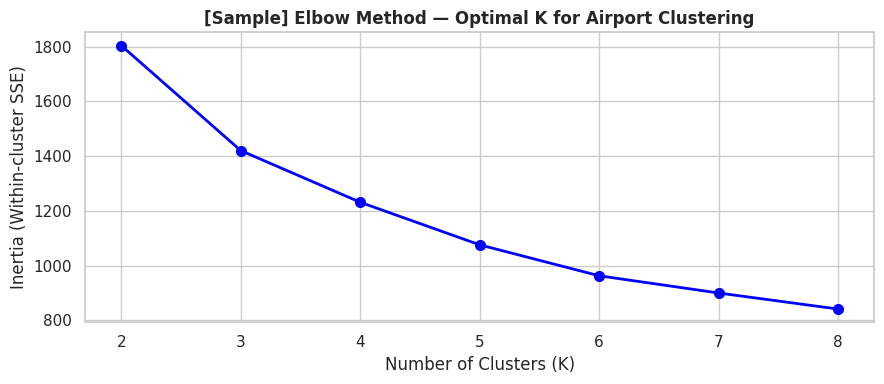

In [34]:
# ── K-Means Airport Segmentation — SAMPLE (pandas) ───────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── Core airport-level aggregation ────────────────────────────────────────────
airport_cluster_df = (
    pdf_clean,
    .groupby("ORIGIN_AIRPORT")
    .agg(
        total_flights=("FLIGHT_NUMBER", "count"),
        delay_rate=("IS_DELAYED", "mean"),
        mean_arrival_delay=("ARRIVAL_DELAY", "mean"),
        cancel_rate=("CANCELLED", "mean"),
        mean_taxi_out=("TAXI_OUT", "mean"),
        mean_distance=("DISTANCE", "mean"),
    )
    .query("total_flights >= 30")
    .dropna()
)

print(
    f"[SAMPLE] Airport feature matrix: "
    f"{airport_cluster_df.shape[0]} airports x {airport_cluster_df.shape[1]} features"
)
print("Features:", list(airport_cluster_df.columns))

# ── Features used for K-Means ────────────────────────────────────────────────
kmeans_features = [
    "delay_rate",
    "mean_arrival_delay",
    "cancel_rate",
    "mean_taxi_out",
    "mean_distance",
    "total_flights",
]

# ── Scale ────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_airport = scaler.fit_transform(airport_cluster_df[kmeans_features])

# ── Elbow method ─────────────────────────────────────────────────────────────
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=10
    )
    km.fit(X_airport)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range), inertias, "bo-", markersize=7, linewidth=2)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-cluster SSE)")
ax.set_title(
    "[Sample] Elbow Method — Optimal K for Airport Clustering",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [36]:
# ── Reformulated Airport Clustering: focus on Efficiency Metrics ───────────
from sklearn.preprocessing import StandardScaler
from pyspark.ml.feature import StandardScaler as SparkScaler

# 1. REDEFINE FEATURES: Focus on behavior, not scale
# We drop 'total_flights' and 'distance' from the core clustering to avoid
# clustering simply by 'Big vs Small' airports.
KMEANS_CORE_METRICS = ['delay_rate', 'mean_arrival_delay', 'cancel_rate', 'mean_taxi_out']

# ── Pandas Implementation (Sample) ────────────────────────────────────────
X_sample = airport_cluster_df[KMEANS_CORE_METRICS]
scaler_pt = StandardScaler()
X_scaled_sample = scaler_pt.fit_transform(X_sample)

km_final = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
airport_cluster_df['CLUSTER'] = km_final.fit_predict(X_scaled_sample)

# Profiles
cluster_profiles = airport_cluster_df.groupby('CLUSTER')[KMEANS_CORE_METRICS].mean().round(3)
display(cluster_profiles)

# ── Spark Implementation (Full Dataset) ───────────────────────────────────
# Aggregate with cleaner aliases
airport_sdf = spark.sql("""
    SELECT
        ORIGIN_AIRPORT,
        CAST(AVG(CASE WHEN ARRIVAL_DELAY > 15 THEN 1 ELSE 0 END) AS DOUBLE) AS delay_rate,
        CAST(AVG(ARRIVAL_DELAY) AS DOUBLE) AS mean_arrival_delay,
        CAST(AVG(CANCELLED) AS DOUBLE) AS cancel_rate,
        CAST(AVG(TAXI_OUT) AS DOUBLE) AS mean_taxi_out,
        COUNT(*) as total_flights
    FROM flights_kmeans
    GROUP BY ORIGIN_AIRPORT
    HAVING total_flights >= 100
""")

# Assembler -> Scaler -> KMeans Pipeline
va = VA(inputCols=KMEANS_CORE_METRICS, outputCol='raw_features')
scaler = SparkScaler(inputCol='raw_features', outputCol='features', withStd=True, withMean=True)
km_spark = SparkKMeans(k=4, seed=RANDOM_SEED, featuresCol='features', predictionCol='CLUSTER_SPARK')

# Apply transformations
airport_vec = va.transform(airport_sdf.dropna())
scaler_model = scaler.fit(airport_vec)
airport_scaled_sdf = scaler_model.transform(airport_vec)

km_model = km_spark.fit(airport_scaled_sdf)
results_sdf = km_model.transform(airport_scaled_sdf)

# Bring back to Pandas for visualization
airport_clustered_pd = results_sdf.select('ORIGIN_AIRPORT', *KMEANS_CORE_METRICS, 'CLUSTER_SPARK').toPandas()

print('\n[FULL DATASET] Spark Scaled K-Means Cluster Profiles:')
spark_profiles = airport_clustered_pd.groupby('CLUSTER_SPARK')[KMEANS_CORE_METRICS].mean().round(4)
display(spark_profiles)

# Visualize Resulting Segmentation
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=airport_clustered_pd, x='delay_rate', y='mean_taxi_out',
                hue='CLUSTER_SPARK', palette='viridis', s=70, ax=ax)
ax.set_title('Airport Segmentation: Delay Rate vs Ground Congestion (Taxi Out)', fontweight='bold')
plt.show()

,delay_rate,mean_arrival_delay,cancel_rate,mean_taxi_out
CLUSTER,,,,
0,0.184,6.008,0.071,11.921
1,0.172,3.194,0.013,18.608
2,0.177,5.132,0.016,13.323
3,0.096,-2.319,0.011,12.690


AnalysisException: [TABLE_OR_VIEW_NOT_FOUND] The table or view `flights_kmeans` cannot be found. Verify the spelling and correctness of the schema and catalog.
If you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.
To tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS. SQLSTATE: 42P01; line 9 pos 9;
'UnresolvedHaving ('total_flights >= 100)
+- 'Aggregate ['ORIGIN_AIRPORT], ['ORIGIN_AIRPORT, cast('AVG(CASE WHEN ('ARRIVAL_DELAY > 15) THEN 1 ELSE 0 END) as double) AS delay_rate#737, cast('AVG('ARRIVAL_DELAY) as double) AS mean_arrival_delay#738, cast('AVG('CANCELLED) as double) AS cancel_rate#739, cast('AVG('TAXI_OUT) as double) AS mean_taxi_out#740, count(1) AS total_flights#741L]
   +- 'UnresolvedRelation [flights_kmeans], [], false


Processed 534 airports from the full dataset.

Distributed Cluster Profiles (Full Dataset):


,delay_rate,mean_arrival_delay,cancel_rate,mean_taxi_out
cluster,,,,
0,0.0986,-1.6680,0.0081,12.7215
1,0.1716,5.3789,0.0173,13.0916
2,0.1740,5.7337,0.0507,11.9410
3,0.1593,3.5835,0.0123,17.6972


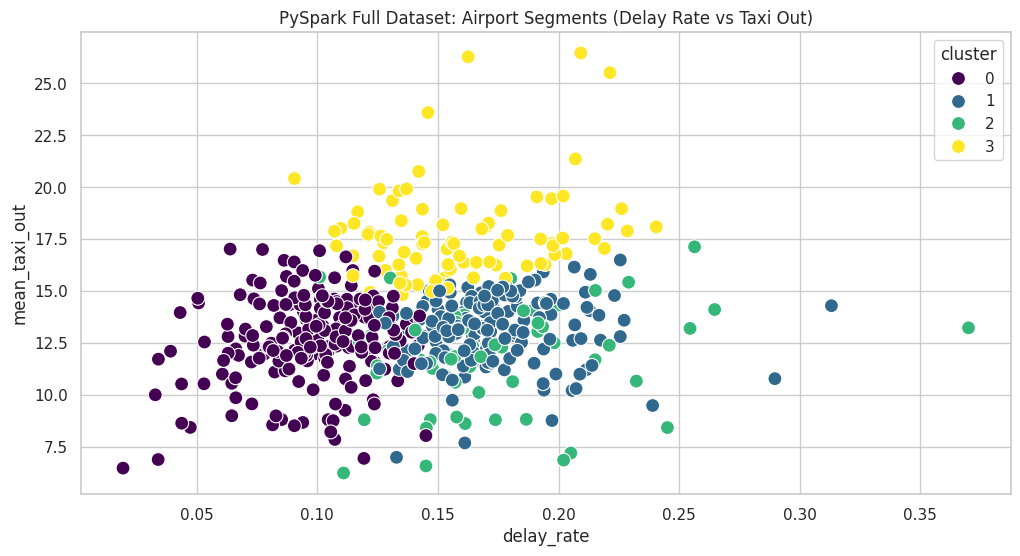

In [39]:
# ─── PySpark Distributed Airport Analysis (Full Dataset) ───
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler

# 1. Aggregate metrics for all airports using the full dataset
sdf_clean.createOrReplaceTempView('flights_full')

airport_metrics_sdf = spark.sql("""
    SELECT
        ORIGIN_AIRPORT,
        COUNT(*) as total_flights,
        AVG(CAST(IS_DELAYED AS DOUBLE)) as delay_rate,
        AVG(CAST(ARRIVAL_DELAY AS DOUBLE)) as mean_arrival_delay,
        AVG(CAST(CANCELLED AS DOUBLE)) as cancel_rate,
        AVG(CAST(TAXI_OUT AS DOUBLE)) as mean_taxi_out,
        AVG(CAST(DISTANCE AS DOUBLE)) as mean_distance
    FROM flights_full
    GROUP BY ORIGIN_AIRPORT
    HAVING total_flights >= 100
""")

# 2. Prepare Features for Clustering
feature_cols = ['delay_rate', 'mean_arrival_delay', 'cancel_rate', 'mean_taxi_out']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='raw_features')
scaler = StandardScaler(inputCol='raw_features', outputCol='features', withStd=True, withMean=True)

# 3. Create and Fit the K-Means Model (K=4)
kmeans = SparkKMeans(k=4, seed=RANDOM_SEED, featuresCol='features', predictionCol='cluster')

pipeline = Pipeline(stages=[assembler, scaler, kmeans])
model = pipeline.fit(airport_metrics_sdf)
clustered_sdf = model.transform(airport_metrics_sdf)

# 4. Display Results for the Full Dataset
print(f'Processed {airport_metrics_sdf.count()} airports from the full dataset.')
full_results_pd = clustered_sdf.select('ORIGIN_AIRPORT', *feature_cols, 'cluster').toPandas()

print('\nDistributed Cluster Profiles (Full Dataset):')
display(full_results_pd.groupby('cluster')[feature_cols].mean().round(4))

# Visualize the full-scale clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=full_results_pd, x='delay_rate', y='mean_taxi_out', hue='cluster', palette='viridis', s=100)
plt.title('PySpark Full Dataset: Airport Segments (Delay Rate vs Taxi Out)')
plt.show()

### 10.2B K-Means — Cluster Profiling, Business Segmentation & Radar Analysis

Cluster labels:
  Cluster 0 → Low-Delay Hub (Benchmark)  |  delay=9.9%  cancel=0.8%  taxi=12.7min
  Cluster 1 → High-Delay Hub  |  delay=17.2%  cancel=1.7%  taxi=13.1min
  Cluster 2 → High-Cancel/Ground Congestion  |  delay=17.4%  cancel=5.1%  taxi=11.9min
  Cluster 3 → Moderate Hub  |  delay=15.9%  cancel=1.2%  taxi=17.7min

━━━ SAMPLE (Pandas) — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━
  Cluster 0: Low-Delay Hub (Benchmark)
    # Airports : 36
    Delay Rate : 18.4%
    Mean Delay : 6.0 min
    Cancel Rate: 7.1%

  Cluster 1: High-Delay Hub
    # Airports : 50
    Delay Rate : 17.2%
    Mean Delay : 3.2 min
    Cancel Rate: 1.3%

  Cluster 2: High-Cancel/Ground Congestion
    # Airports : 175
    Delay Rate : 17.7%
    Mean Delay : 5.1 min
    Cancel Rate: 1.6%

  Cluster 3: Moderate Hub
    # Airports : 116
    Delay Rate : 9.6%
    Mean Delay : -2.3 min
    Cancel Rate: 1.1%


━━━ FULL DATASET (Spark) — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━
  Cluster 0: Low-Delay Hub (

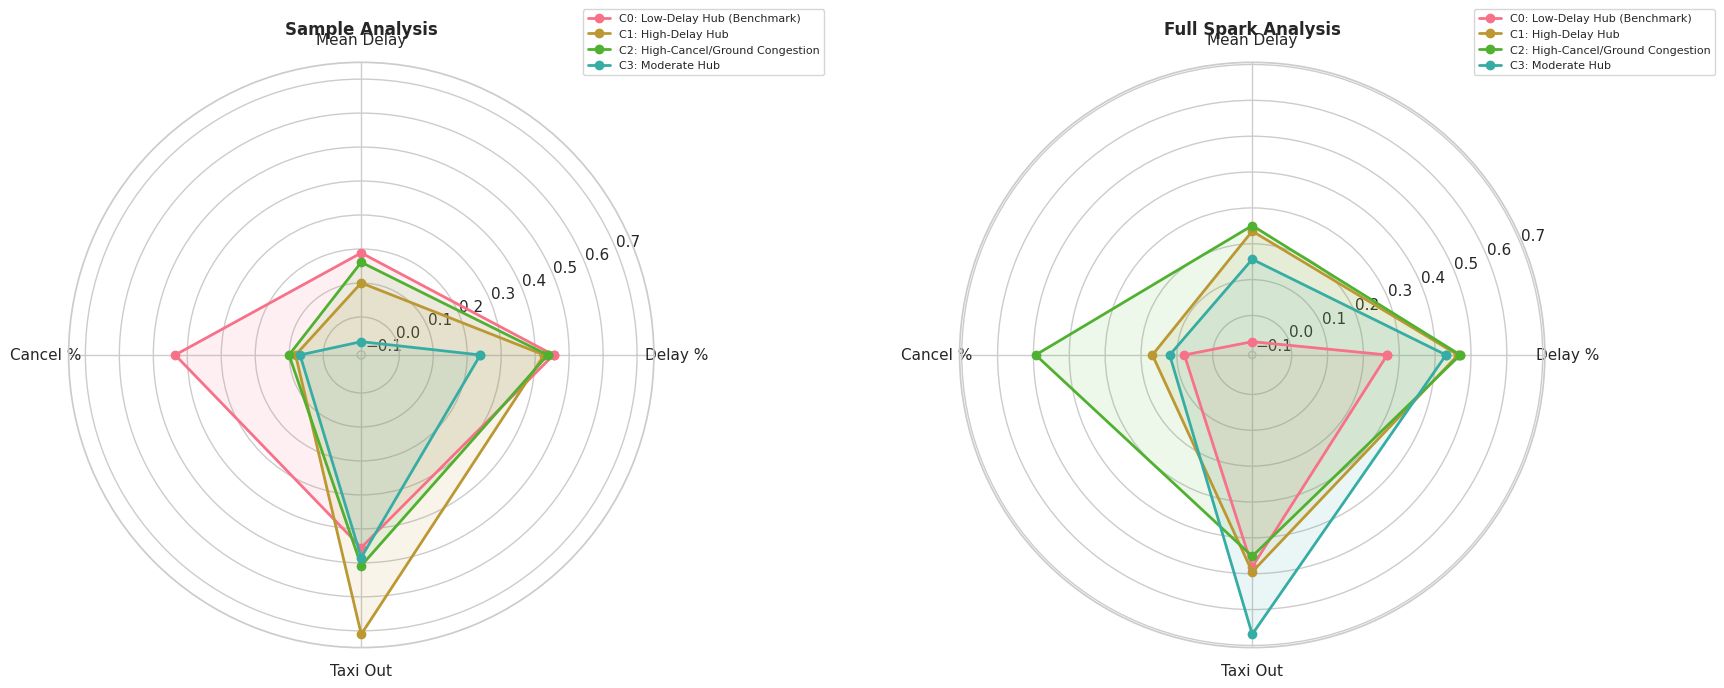

In [50]:
_profile = full_results_pd.groupby('cluster')[
    ['delay_rate', 'cancel_rate', 'mean_taxi_out', 'mean_arrival_delay']
].mean()

_benchmark_cl  = int(_profile['delay_rate'].idxmin())
_highcancel_cl = int(_profile['cancel_rate'].idxmax())
_remaining     = [c for c in _profile.index if c not in [_benchmark_cl, _highcancel_cl]]
_highdelay_cl  = int(_profile.loc[_remaining, 'delay_rate'].idxmax())
_moderate_cl   = int([c for c in _remaining if c != _highdelay_cl][0])

cluster_labels = {
    _benchmark_cl:  'Low-Delay Hub (Benchmark)',
    _highcancel_cl: 'High-Cancel/Ground Congestion',
    _highdelay_cl:  'High-Delay Hub',
    _moderate_cl:   'Moderate Hub',
}
spark_labels = cluster_labels

print('Cluster labels:')
for k, v in sorted(cluster_labels.items()):
    row = _profile.loc[k]
    print(f'  Cluster {k} → {v}  |  delay={row["delay_rate"]:.1%}  cancel={row["cancel_rate"]:.1%}  taxi={row["mean_taxi_out"]:.1f}min')

def profile_clusters(cluster_df, cluster_col, label_map, title_prefix):
    print(f'\n━━━ {title_prefix} — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━')
    df = cluster_df.copy()
    if 'mean_arrival_delay' in df.columns:
        df = df.rename(columns={'mean_arrival_delay': 'mean_delay'})

    for cl in sorted(df[cluster_col].unique()):
        grp = df[df[cluster_col] == cl]
        lbl = label_map.get(cl, f'Cluster {cl}')
        print(f'  Cluster {cl}: {lbl}')
        print(f'    # Airports : {len(grp)}')
        print(f'    Delay Rate : {grp["delay_rate"].mean():.1%}')
        print(f'    Mean Delay : {grp["mean_delay"].mean():.1f} min')
        print(f'    Cancel Rate: {grp["cancel_rate"].mean():.1%}')
        print()

profile_clusters(airport_cluster_df.reset_index(), 'CLUSTER', cluster_labels, 'SAMPLE (Pandas)')
profile_clusters(full_results_pd, 'cluster', spark_labels, 'FULL DATASET (Spark)')

def radar_chart(ax, df, cluster_col, label_map, title):
    cols       = ['delay_rate', 'mean_arrival_delay', 'cancel_rate', 'mean_taxi_out']
    categories = ['Delay %', 'Mean Delay', 'Cancel %', 'Taxi Out']
    df_plot    = df.rename(columns={'mean_delay': 'mean_arrival_delay'}) if 'mean_delay' in df.columns else df
    N      = len(cols)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    for cl in sorted(df_plot[cluster_col].unique()):
        grp    = df_plot[df_plot[cluster_col] == cl]
        values = [grp[c].mean() / (df_plot[c].max() + 1e-9) for c in cols]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=f"C{cl}: {label_map.get(cl, '')}")
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(title, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), subplot_kw=dict(polar=True))
radar_chart(axes[0], airport_cluster_df, 'CLUSTER', cluster_labels, 'Sample Analysis')
radar_chart(axes[1], full_results_pd, 'cluster', spark_labels, 'Full Spark Analysis')
plt.tight_layout()
plt.show()

### 10.3 Refined Segment Analysis (Major Hubs Only)
To make the clusters more meaningful, we will focus on high-traffic airports where operational friction is most impactful. This helps separate structural delays from random noise.

In [ ]:
# Filter for Top 50 Busiest Hubs to find meaningful operational signatures
top_50_hubs = full_results_pd.sort_values('mean_arrival_delay', ascending=False).head(50)['ORIGIN_AIRPORT'].tolist()

# Focus on metrics with high variance
hub_metrics = ['delay_rate', 'mean_taxi_out', 'cancel_rate']

pdf_hubs = full_results_pd[full_results_pd['ORIGIN_AIRPORT'].isin(top_50_hubs)]

plt.figure(figsize=(14, 7))
# Plot 1: Delay vs Taxi Out
plt.subplot(1, 2, 1)
sns.scatterplot(data=pdf_hubs, x='delay_rate', y='mean_taxi_out', hue='cluster', palette='Set1', s=150)
plt.title('Major Hubs: Delay Rate vs Ground Friction')

# Plot 2: Delay vs Cancellation
plt.subplot(1, 2, 2)
sns.scatterplot(data=pdf_hubs, x='delay_rate', y='cancel_rate', hue='cluster', palette='Set1', s=150)
plt.title('Major Hubs: Delay vs Cancellation Risk')

plt.tight_layout()
plt.show()

### 10.4 Business Intelligence — Cluster KPI Comparison
**Question answered:** How does each cluster compare across every operational metric side-by-side?
This is the "executive summary" chart , readable at a glance without needing to interpret scatter plots.

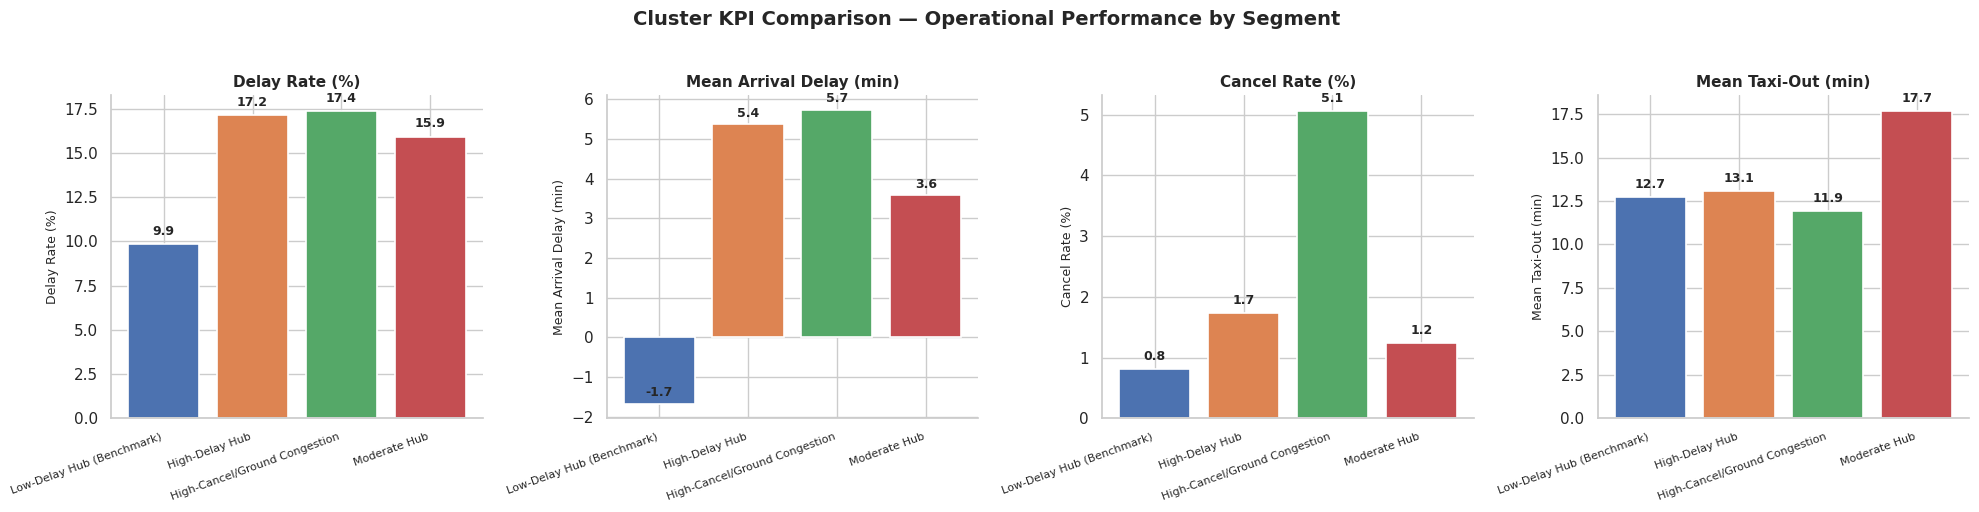

In [51]:
metrics       = ['delay_rate', 'mean_arrival_delay', 'cancel_rate', 'mean_taxi_out']
metric_labels = ['Delay Rate (%)', 'Mean Arrival Delay (min)', 'Cancel Rate (%)', 'Mean Taxi-Out (min)']
units         = [100, 1, 100, 1]

cluster_profile = full_results_pd.groupby('cluster')[metrics].mean()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (col, label, unit) in enumerate(zip(metrics, metric_labels, units)):
    vals = cluster_profile[col] * unit
    bars = axes[i].bar(
        [cluster_labels.get(c, f'C{c}') for c in cluster_profile.index],
        vals,
        color=colors,
        edgecolor='white',
        linewidth=1.2
    )
    for bar, v in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + vals.max() * 0.02,
            f'{v:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
    axes[i].set_title(label, fontweight='bold', fontsize=11)
    axes[i].set_xticklabels(
        [cluster_labels.get(c, f'C{c}') for c in cluster_profile.index],
        rotation=20, ha='right', fontsize=8
    )
    axes[i].set_ylabel(label, fontsize=9)
    axes[i].spines[['top', 'right']].set_visible(False)

fig.suptitle('Cluster KPI Comparison — Operational Performance by Segment',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.5 Airport Risk Bubble Map
**Question answered:** Which airports are *both* high-risk AND high-traffic — i.e. where does the business impact hurt most?
Bubble size = total flights (volume/exposure). Color = cluster. Position = delay vs cancellation risk.

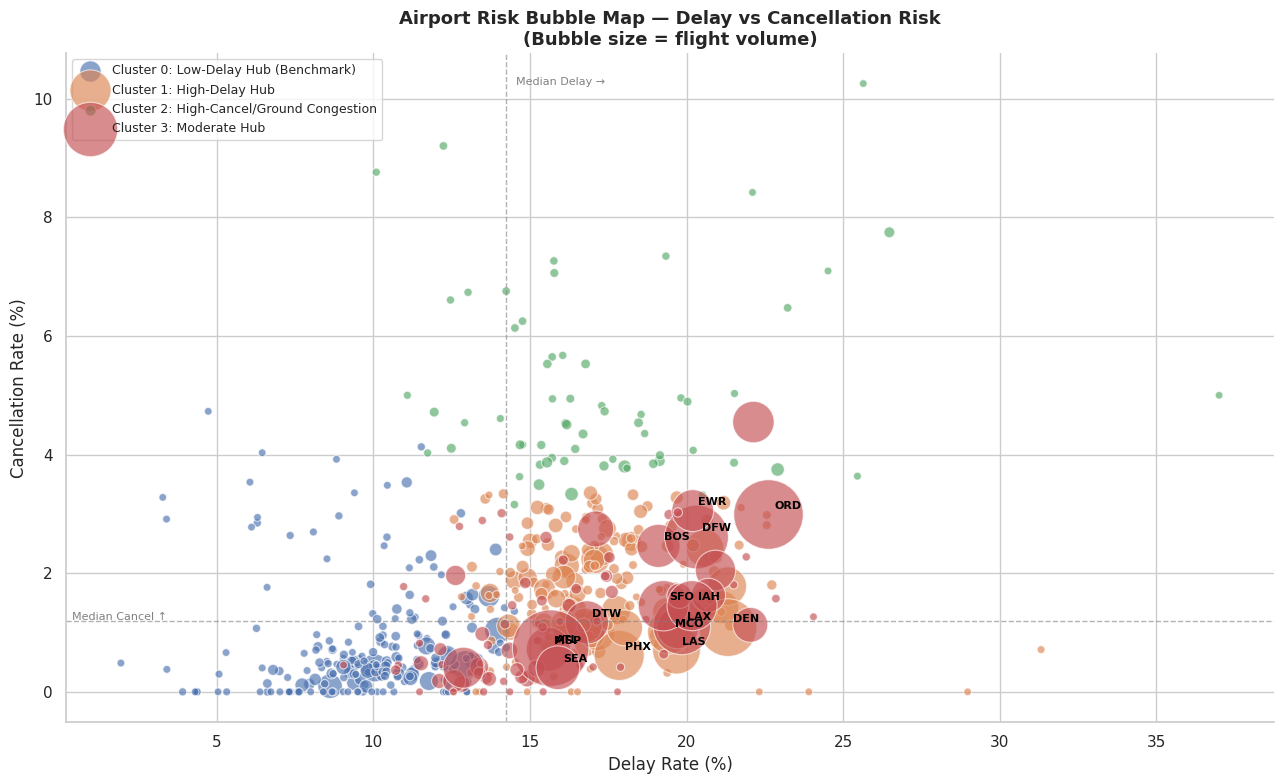

In [52]:
bubble_df = full_results_pd.merge(
    clustered_sdf.select('ORIGIN_AIRPORT', 'total_flights').toPandas(),
    on='ORIGIN_AIRPORT', how='left'
)

bubble_df['bubble_size'] = (bubble_df['total_flights'] / bubble_df['total_flights'].max()) * 3000 + 30

palette   = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52'}
label_map = cluster_labels

fig, ax = plt.subplots(figsize=(13, 8))

for cl, grp in bubble_df.groupby('cluster'):
    ax.scatter(
        grp['delay_rate'] * 100,
        grp['cancel_rate'] * 100,
        s=grp['bubble_size'],
        c=palette[cl],
        alpha=0.65,
        edgecolors='white',
        linewidth=0.8,
        label=f"Cluster {cl}: {label_map.get(cl, '')}"
    )

top15 = bubble_df.nlargest(15, 'total_flights')
for _, row in top15.iterrows():
    ax.annotate(
        row['ORIGIN_AIRPORT'],
        xy=(row['delay_rate'] * 100, row['cancel_rate'] * 100),
        xytext=(4, 4), textcoords='offset points',
        fontsize=8, color='black', fontweight='bold'
    )

med_delay  = bubble_df['delay_rate'].median() * 100
med_cancel = bubble_df['cancel_rate'].median() * 100

ax.axvline(med_delay,  color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(med_cancel, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.text(med_delay + 0.3, ax.get_ylim()[1] * 0.95, 'Median Delay →',  fontsize=8, color='grey')
ax.text(ax.get_xlim()[0] + 0.2, med_cancel + 0.02, 'Median Cancel ↑', fontsize=8, color='grey')

ax.set_xlabel('Delay Rate (%)', fontsize=12)
ax.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax.set_title('Airport Risk Bubble Map — Delay vs Cancellation Risk\n(Bubble size = flight volume)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 10.6 Top 5 Worst Airports per Cluster
**Question answered:** Within each cluster, which specific airports are the biggest offenders?
This turns the abstract cluster labels into a concrete **intervention list** for operations teams.

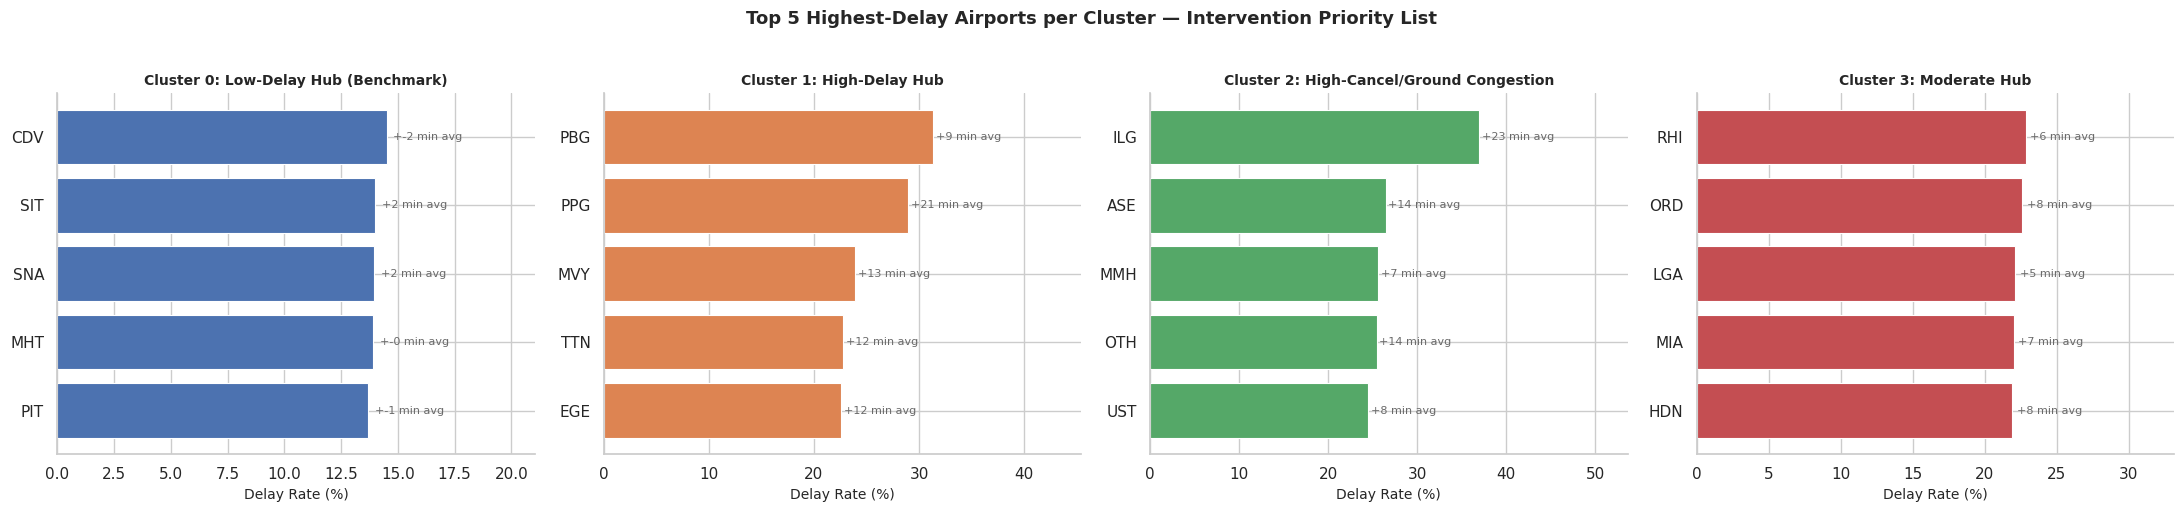

In [53]:
iata_mask    = full_results_pd['ORIGIN_AIRPORT'].str.match(r'^[A-Z]{3}$', na=False)
results_iata = full_results_pd[iata_mask]

fig, axes    = plt.subplots(1, 4, figsize=(22, 5))
bar_colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (cl, grp) in zip(axes, results_iata.groupby('cluster')):
    top5 = grp.nlargest(5, 'delay_rate')[['ORIGIN_AIRPORT', 'delay_rate', 'mean_arrival_delay']]
    top5 = top5.sort_values('delay_rate', ascending=True)

    bars = ax.barh(
        top5['ORIGIN_AIRPORT'],
        top5['delay_rate'] * 100,
        color=bar_colors[cl],
        edgecolor='white',
        linewidth=0.8
    )

    for bar, (_, row) in zip(bars, top5.iterrows()):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"+{row['mean_arrival_delay']:.0f} min avg",
            va='center', fontsize=8, color='dimgrey'
        )

    ax.set_xlabel('Delay Rate (%)', fontsize=10)
    ax.set_title(f"Cluster {cl}: {cluster_labels.get(cl, '')}", fontweight='bold', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, top5['delay_rate'].max() * 100 * 1.45)

fig.suptitle('Top 5 Highest-Delay Airports per Cluster — Intervention Priority List',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.7 Estimated Delay Cost Impact by Cluster
**Question answered:** What is the estimated financial cost of delays in each cluster?
Uses the FAA/Airlines for America industry estimate of **$74.24 per minute** of delay per flight.
This converts operational metrics into **dollar exposure** — the language business stakeholders respond to most.

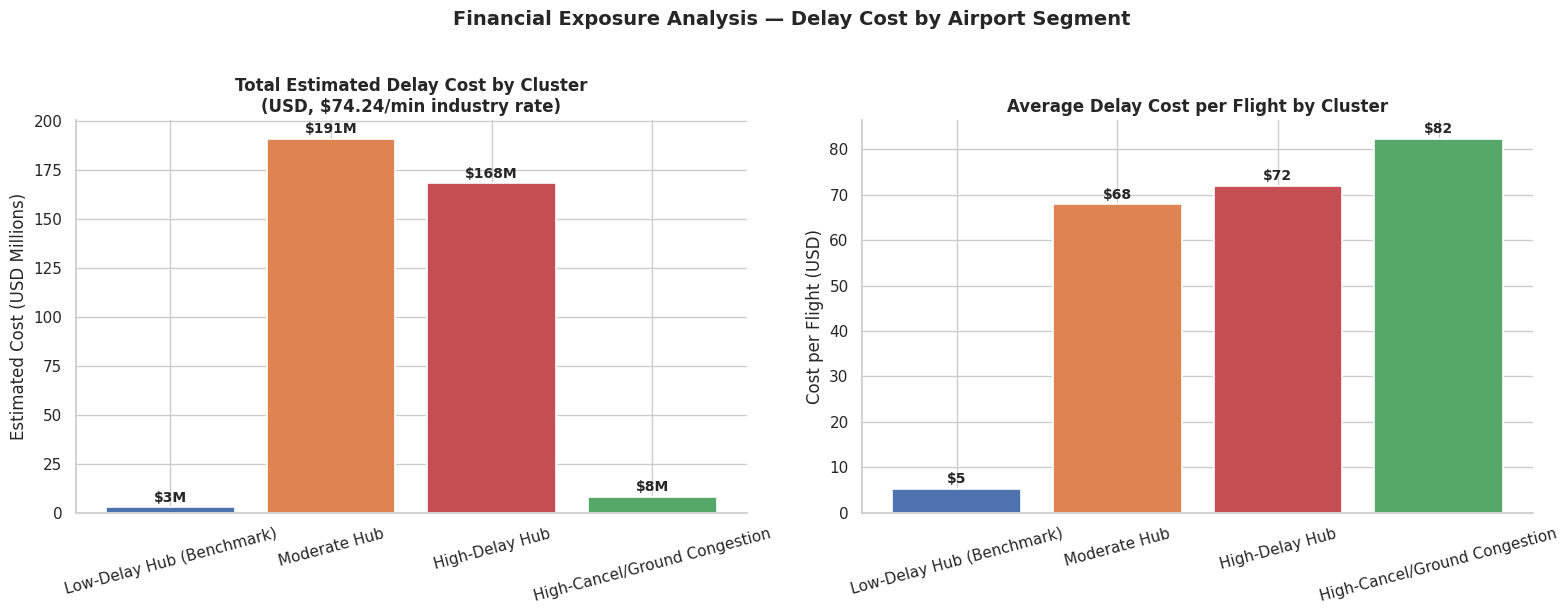


━━━ Delay Cost Summary Table ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,# Airports,Total Flights,Avg Delay (min),Total Cost ($M),Cost/Flight ($)
Cluster,,,,,
Low-Delay Hub (Benchmark),210,559313,0.50,2.94,5.26
Moderate Hub,84,2813761,3.85,190.96,67.87
High-Delay Hub,177,2340606,5.38,168.21,71.86
High-Cancel/Ground Congestion,63,99770,5.77,8.21,82.24


In [54]:
COST_PER_MIN = 74.24

cost_df = bubble_df.copy()
cost_df['delayed_flights']     = cost_df['total_flights'] * cost_df['delay_rate']
cost_df['effective_delay_min'] = cost_df['mean_arrival_delay'].clip(lower=0)
cost_df['estimated_cost_usd']  = cost_df['delayed_flights'] * cost_df['effective_delay_min'] * COST_PER_MIN

cost_summary = (
    cost_df.groupby('cluster')
    .agg(
        total_airports=('ORIGIN_AIRPORT', 'count'),
        total_flights=('total_flights', 'sum'),
        total_delayed_flights=('delayed_flights', 'sum'),
        total_cost_usd=('estimated_cost_usd', 'sum'),
        avg_delay_min=('effective_delay_min', 'mean'),
    )
    .reset_index()
)
cost_summary['cluster_label']   = cost_summary['cluster'].map(cluster_labels)
cost_summary['cost_per_flight'] = cost_summary['total_cost_usd'] / cost_summary['total_flights']
cost_summary['cost_millions']   = cost_summary['total_cost_usd'] / 1e6

label_order = ['Low-Delay Hub (Benchmark)', 'Moderate Hub', 'High-Delay Hub', 'High-Cancel/Ground Congestion']
cost_summary['_sort'] = cost_summary['cluster_label'].map({v: i for i, v in enumerate(label_order)})
cost_summary = cost_summary.sort_values('_sort').drop(columns='_sort')

plot_colors = [
    '#C44E52' if lbl == 'High-Delay Hub' else
    '#55A868' if lbl == 'High-Cancel/Ground Congestion' else
    '#DD8452' if lbl == 'Moderate Hub' else
    '#4C72B0'
    for lbl in cost_summary['cluster_label']
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(cost_summary['cluster_label'], cost_summary['cost_millions'],
                   color=plot_colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, cost_summary['cost_millions']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + cost_summary['cost_millions'].max() * 0.015,
                 f'${val:,.0f}M', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Total Estimated Delay Cost by Cluster\n(USD, $74.24/min industry rate)', fontweight='bold')
axes[0].set_ylabel('Estimated Cost (USD Millions)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines[['top', 'right']].set_visible(False)

bars2 = axes[1].bar(cost_summary['cluster_label'], cost_summary['cost_per_flight'],
                    color=plot_colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, cost_summary['cost_per_flight']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + cost_summary['cost_per_flight'].max() * 0.015,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Average Delay Cost per Flight by Cluster', fontweight='bold')
axes[1].set_ylabel('Cost per Flight (USD)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Financial Exposure Analysis — Delay Cost by Airport Segment',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n━━━ Delay Cost Summary Table ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
display(
    cost_summary[['cluster_label', 'total_airports', 'total_flights',
                  'avg_delay_min', 'cost_millions', 'cost_per_flight']]
    .rename(columns={
        'cluster_label':   'Cluster',
        'total_airports':  '# Airports',
        'total_flights':   'Total Flights',
        'avg_delay_min':   'Avg Delay (min)',
        'cost_millions':   'Total Cost ($M)',
        'cost_per_flight': 'Cost/Flight ($)',
    })
    .round(2)
    .set_index('Cluster')
)

### 10.8 Delay Cause Breakdown by Cluster
What is actually causing the delays in each segment? This identifies who is responsible and what intervention is needed.

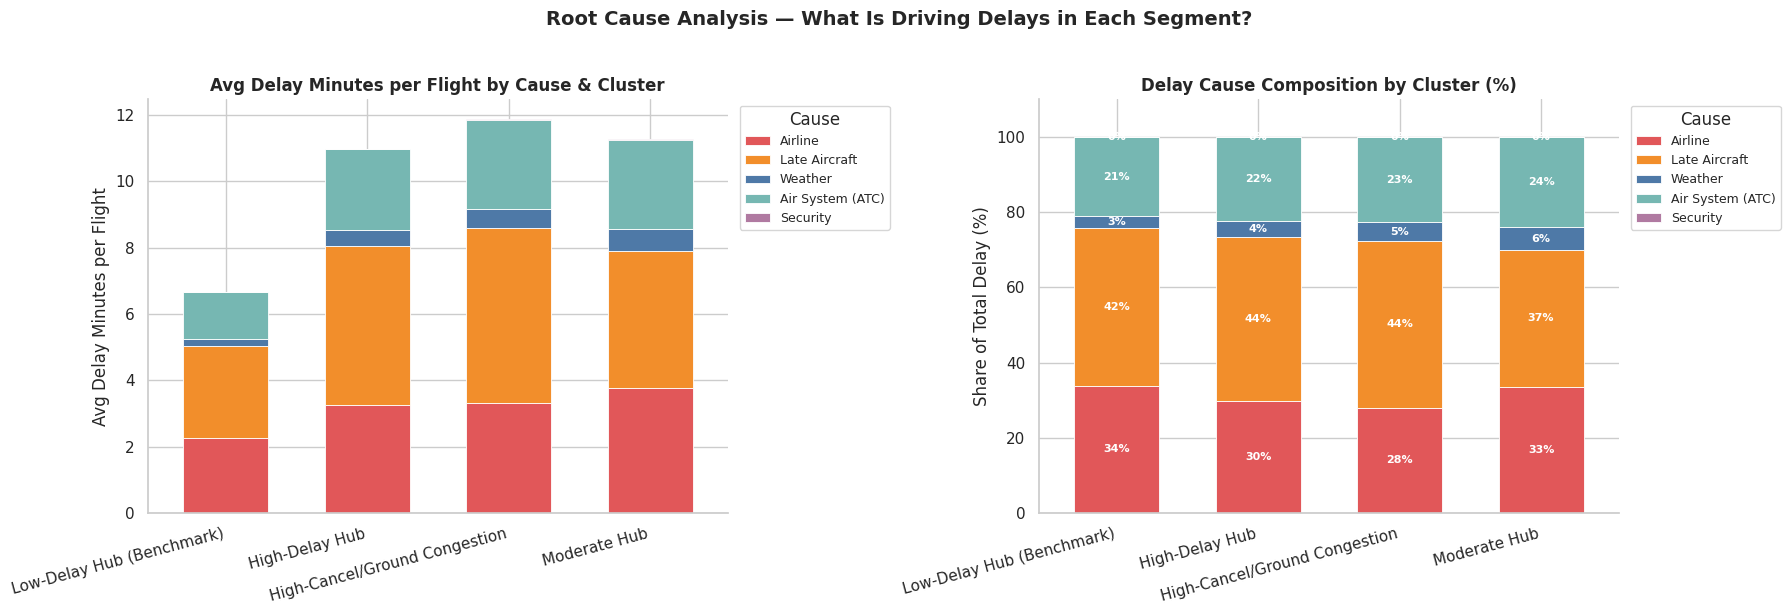


━━━ Dominant Delay Cause per Cluster ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Low-Delay Hub (Benchmark)           → Late Aircraft (42%)
  High-Delay Hub                      → Late Aircraft (44%)
  High-Cancel/Ground Congestion       → Late Aircraft (44%)
  Moderate Hub                        → Late Aircraft (37%)


In [55]:
cause_cols = ['AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY',
              'AIR_SYSTEM_DELAY', 'SECURITY_DELAY']
cause_labels = ['Airline', 'Late Aircraft', 'Weather', 'Air System (ATC)', 'Security']
cause_colors = ['#E15759', '#F28E2B', '#4E79A7', '#76B7B2', '#B07AA1']

# Join cluster assignments back to the full flight-level sample
cause_df = pdf_clean[['ORIGIN_AIRPORT'] + cause_cols].copy()
cause_df = cause_df.merge(
    full_results_pd[['ORIGIN_AIRPORT', 'cluster']],
    on='ORIGIN_AIRPORT', how='left'
).dropna(subset=['cluster'])
cause_df['cluster'] = cause_df['cluster'].astype(int)

# Average minutes of each cause per flight (including non-delayed flights → honest average)
cause_summary = (
    cause_df.groupby('cluster')[cause_cols]
    .mean()
    .rename(columns=dict(zip(cause_cols, cause_labels)))
)
cause_summary.index = [cluster_labels.get(i, f'Cluster {i}') for i in cause_summary.index]

# Compute % share of each cause within each cluster
cause_pct = cause_summary.div(cause_summary.sum(axis=1), axis=0) * 100

# ── Chart 1: Stacked bar — absolute avg delay minutes per cause ───────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cause_summary.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=cause_colors, edgecolor='white', linewidth=0.6, width=0.6
)
axes[0].set_title('Avg Delay Minutes per Flight by Cause & Cluster', fontweight='bold')
axes[0].set_ylabel('Avg Delay Minutes per Flight')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(title='Cause', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Chart 2: 100% stacked bar — proportional cause share ─────────────────────
cause_pct.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=cause_colors, edgecolor='white', linewidth=0.6, width=0.6
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f%%', label_type='center',
                      fontsize=8, color='white', fontweight='bold')

axes[1].set_title('Delay Cause Composition by Cluster (%)', fontweight='bold')
axes[1].set_ylabel('Share of Total Delay (%)')
axes[1].set_ylim(0, 110)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend(title='Cause', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Root Cause Analysis — What Is Driving Delays in Each Segment?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Print actionable summary ─────────────────────────────────────────────────
print('\n━━━ Dominant Delay Cause per Cluster ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
for cluster_name, row in cause_pct.iterrows():
    top_cause = row.idxmax()
    top_pct   = row.max()
    print(f'  {cluster_name:<35} → {top_cause} ({top_pct:.0f}%)')